### Постановка задачи

**Задание**
1. Выберите наиболее релевантную выборку пользователей для проведения
анализа.
2. Для каждого пользователя рассчитайте Recency, Frequency, Monetary по
описанному выше алгоритму.
3. Дайте оценку RFM. Сгруппируйте пользователей по категориям.
4. Постройте графики и сделайте выводы.

**Таблица data:**
* InvoiceNo – номер заказа
* StockCode – код акции
* Description – название акции
* Quantity – количество единиц товара в заказе
* InvoiceDate – дата заказа
* UnitPrice – цена единицы товара
* CustomerID – идентификатор пользователя
* Country – страна

### Загрузка и первичная обработка данных

In [109]:
import pandas as pd
import os 
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns 

In [45]:
# загрузка данных - у всех одинаковая
os.chdir(r'C:\Users\pasht\OneDrive\Документы\4 курс 1 семестр\прикладная аналитика\практическая 7')
df = pd.read_csv('data.csv', encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [67]:
#выведите описательные статистики датасета
print(df.describe(), '\nДлина датасета:', df.shape[0], '\nПропущенные значения:\n', df.isna().sum())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000 
Длина датасета: 541909 
Пропущенные значения:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [73]:
#удалим NaN 
clean_df = df.dropna(subset = ['CustomerID']) #удалим наны только по юзер айди, 
#потому что у нас наны есть только в этом столбце и в названии акции, а отсутствие названия акции не помешает провести  RFM-сегментацию
clean_df.shape[0]

406829

In [75]:
#Удалим отрицательные значения
clean_df = clean_df[(clean_df['Quantity'] >= 0) & (clean_df['UnitPrice'] >= 0) & (clean_df['CustomerID'] >= 0)] 
clean_df.shape[0]

397924

In [81]:
clean_df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


### RFM - сегментация

In [93]:
#есть подозрения что кол-во и распределение данных по странам несопоставими и их нельзя брать вместе
clean_df['Country'].value_counts()

Country
United Kingdom          354345
Germany                   9042
France                    8342
EIRE                      7238
Spain                     2485
Netherlands               2363
Belgium                   2031
Switzerland               1842
Portugal                  1462
Australia                 1185
Norway                    1072
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         58
Lebanon                     45


In [95]:
#посмотрим на средний чек и количество покупок по странам
country_df = clean_df.groupby('Country').agg({'UnitPrice':'mean', 'Quantity':'mean'}) 
country_df

,UnitPrice,Quantity
Country,,
Australia,3.048523,71.062447
Austria,4.256030,12.263819
Bahrain,4.644118,15.294118
Belgium,3.630158,11.441162
Brazil,4.456250,11.125000
Canada,6.030331,18.298013
Channel Islands,4.531618,12.688503
Cyprus,5.710391,10.359935
Czech Republic,3.130800,26.840000


### Делать RFM сегментацию по всем странам некорректно: у нас гигантский перекос — United Kingdom составляет около 78% всех заказов (354k из ~450k), а значит сегментация по всем странам будет просто RFM по британцам с шумом вокруг. Также очень важно, что остальные страны сильно отличаются по средним чекам (например, Singapore со средним UnitPrice 58 против UK, где средний UnitPrice 2,96) их нельзя сравнивать напрямую.

### Поэтому мы будем делать RFM только по United Kingdom — там больше всего данных

In [160]:
#выберите релевантную выборку (выбрать пользователей по какому-то качественному признаку, исходя из цели RFM-анализа, которую Вы сформулируете)
df_sample = clean_df[clean_df['Country'] == 'United Kingdom']
df_sample.shape

(354345, 8)

In [127]:
df_sample.describe()

,Quantity,UnitPrice,CustomerID
count,354345.000000,354345.000000,354345.000000
mean,12.048913,2.963793,15552.436219
std,190.428127,17.862067,1594.546025
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,14194.000000
50%,4.000000,1.950000,15522.000000
75%,12.000000,3.750000,16931.000000
max,80995.000000,8142.750000,18287.000000


In [156]:
df_sample_price_zero = df_sample.query('UnitPrice == 0') 
df_sample_quantity_zero = df_sample.query('Quantity == 0') 
df_sample_price_zero.shape
#df_sample_quantity_zero.shape

(0, 8)

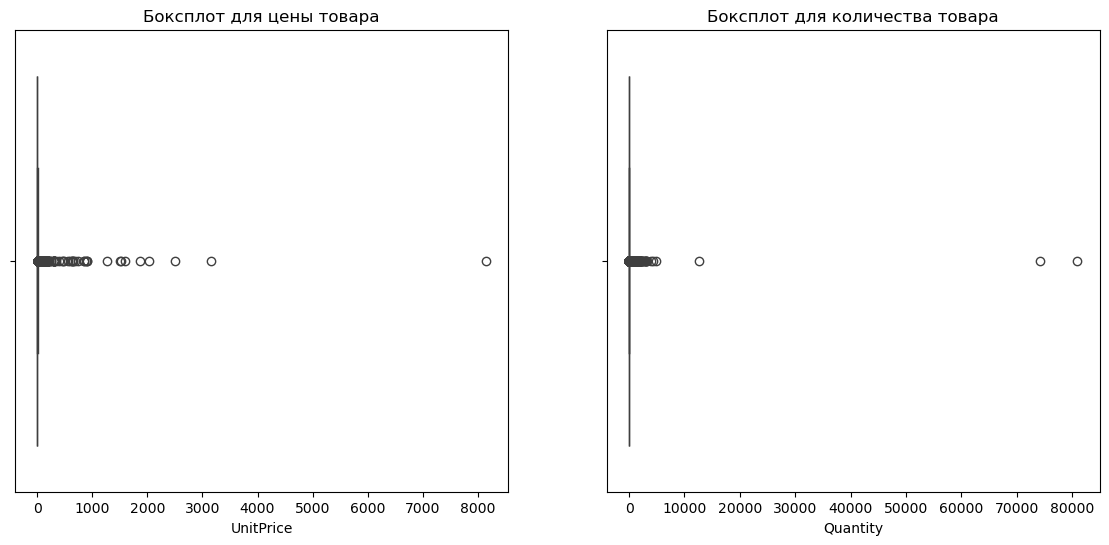

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_sample, x='UnitPrice', ax=axes[0])
axes[0].set_title('Боксплот для цены товара')

sns.boxplot(data=df_sample, x='Quantity', ax=axes[1])
axes[1].set_title('Боксплот для количества товара')

plt.show()

### У нас есть несколько очевидных аномалий, ликвидируем их

In [164]:
#удалим их через фильтрацию
df_sample = df_sample[(df_sample['UnitPrice'] < 6000) & (df_sample['Quantity'] < 6000)]

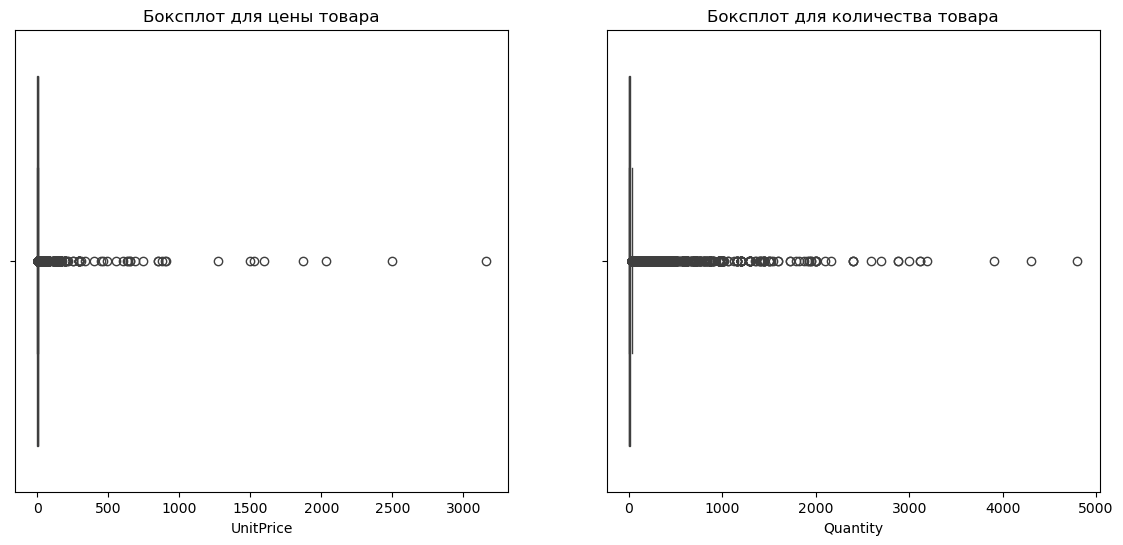

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_sample, x='UnitPrice', ax=axes[0])
axes[0].set_title('Боксплот для цены товара')

sns.boxplot(data=df_sample, x='Quantity', ax=axes[1])
axes[1].set_title('Боксплот для количества товара')

plt.show()

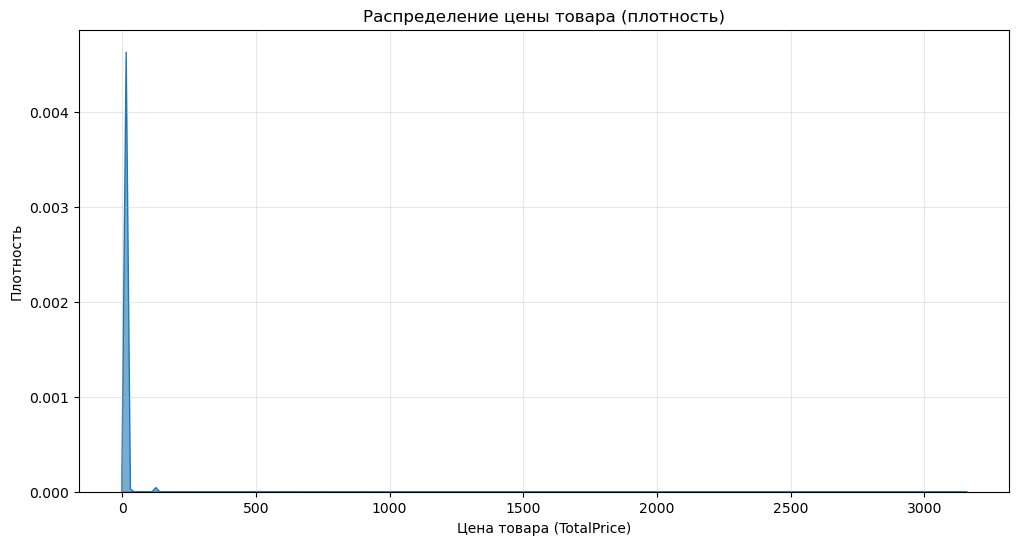

In [170]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_sample['UnitPrice'],fill = True,  alpha=0.6)
plt.title('Распределение цены товара (плотность)')
plt.xlabel('Цена товара (TotalPrice)')
plt.ylabel('Плотность')
plt.grid(True, alpha=0.3)
plt.show()

In [168]:
#посчитайте выручку, это необходимо для Monetary
df_sample['Revenue'] = df_sample['Quantity']*df_sample['UnitPrice']

In [178]:
pd.to_datetime(df_date)

TypeError: to_datetime() missing 1 required positional argument: 'arg'

In [176]:
#готовим данные для RFM
data_forRFM = df_sample.groupby('CustomerID').agg({'Revenue': 'sum', 'InvoiceDate':'max', 'InvoiceNo':'count'}).reset_index()

data_forRFM = data_forRFM.rename(columns={
    'Revenue': 'Monetary',
    'InvoiceDate': 'MaxDate',
    'InvoiceNo': 'Frequency'
})
data_forRFM

,CustomerID,Monetary,MaxDate,Frequency
0,12747.0,4196.01,8/22/2011 10:38,103
1,12748.0,33719.73,9/9/2011 13:20,4596
2,12749.0,4090.88,8/1/2011 12:50,199
3,12820.0,942.34,9/26/2011 11:49,59
4,12821.0,92.72,5/9/2011 15:51,6
...,...,...,...,...
3914,18280.0,180.60,3/7/2011 9:52,10
3915,18281.0,80.82,6/12/2011 10:53,7
3916,18282.0,178.05,8/5/2011 13:35,12
3917,18283.0,2094.88,9/5/2011 12:35,756


In [50]:
#рассчитаем показатель Recency (давность)
#найдите последнюю (максимальную) дату  покупки (надо работать со столбцом InvoiceDate)
data_forRFM['MaxDate'] = max(...)

In [ ]:
#найдите разницу в днях между самой поздней датой в датасете с последней датой покупки каждого клиента
data_forRFM['Recency'] = data_forRFM[...] - ...

In [ ]:
#выведите описательные статистики для формирования групп

In [54]:
#после того, как мы сформировали все показатели, начинаем разбивать их на категории

#пишем функцию, которая автоматически определяет группы по показателям исходя из их значений
#ориентируйтесь на описательные статистики (подставьте необходимые значения вместо точек)
def monetary_groups(m):
    if m >= .....:
        return '1'
    elif m >= ....:
        return '2'
    else:
        return '3'

# применяем эту функцию к столбцу 'Monetary' и создаем новый столбец 'M'
data_forRFM['M'] = data_forRFM['Monetary'].apply(monetary_groups)

In [56]:
#аналогично делаем для всех оставшихся показателей

In [57]:
#визуализация

### Выводы по анализу:
...